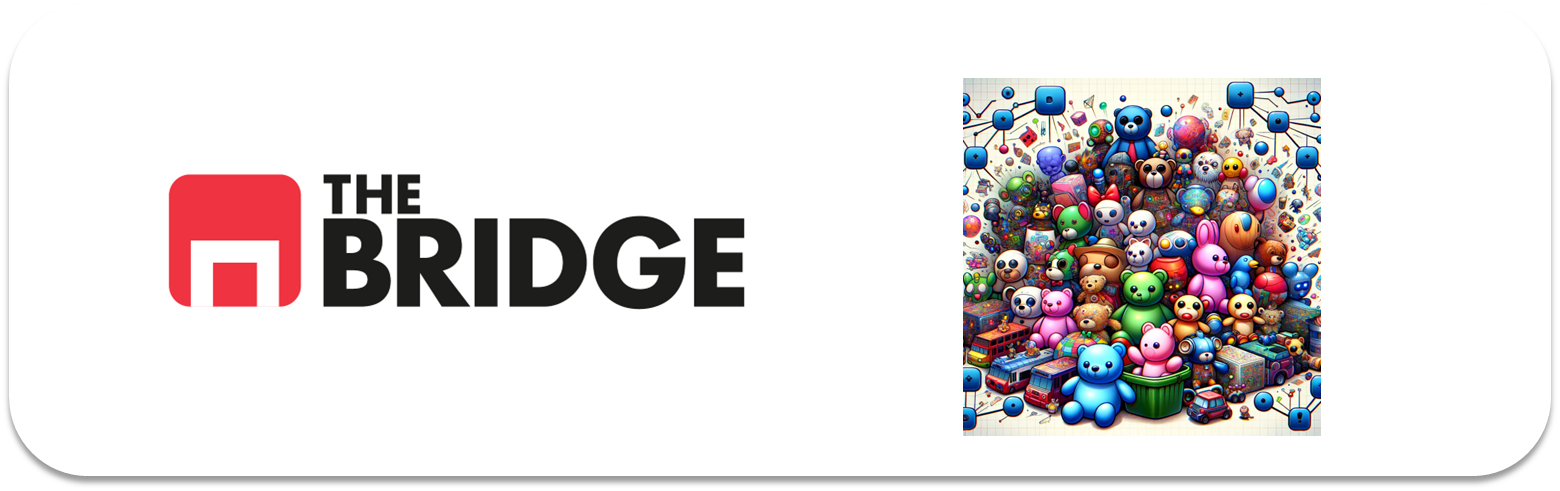

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

from itertools import combinations
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from scipy.cluster.hierarchy import dendrogram, linkage

pd.options.mode.copy_on_write = True

C:\Users\MartaEstevez\AppData\Local\Temp\ipykernel_24936\3154279013.py:13: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


### 1. Entender el problema
El problema es de clustering no supervisado. No tenemos etiquetas así que tenemos que usar algoritmos como DBSCAN o clustering jerárquico para encontrar grupos en los datos. Según el enunciado esperamos entre 3 y 5 clusters.

Con DBSCAN no controlamos directamente el número de clusters, lo hacemos ajustando eps y min_samples. Con el jerárquico usaremos el dendrograma para decidir cuántos clusters tiene sentido.

### 2.Carga de datos y visualización

In [4]:
train_set = pd.read_csv("./data/empowering_drinks.csv", sep = "|")
train_set

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276
...,...,...,...,...,...
148,0.493343,0.414820,-1.284344,0.009893,0.969783
149,0.332758,-0.389355,-1.344582,0.280575,2.224236
150,0.209232,0.012732,-1.354622,0.296498,1.834923
151,1.395086,1.365208,-1.274305,-0.595160,1.791666


In [5]:
train_set.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


In [6]:
train_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


El dataset tiene 153 filas y 5 columnas con los componentes de las bebidas. Las medias hemos visto que están cerca de cero y las desviaciones estándar están cerca de uno así que parace que ya están los datos escalados. No hay tampoco valores nulos así que tenemos el dataset perfecto para trabajar.

### 3. Mini EDA
Ahora toca explorar las relaciones entre variables para ver si ya se intuyen clusters visualmente y para decidir qué features usar en el modelo.

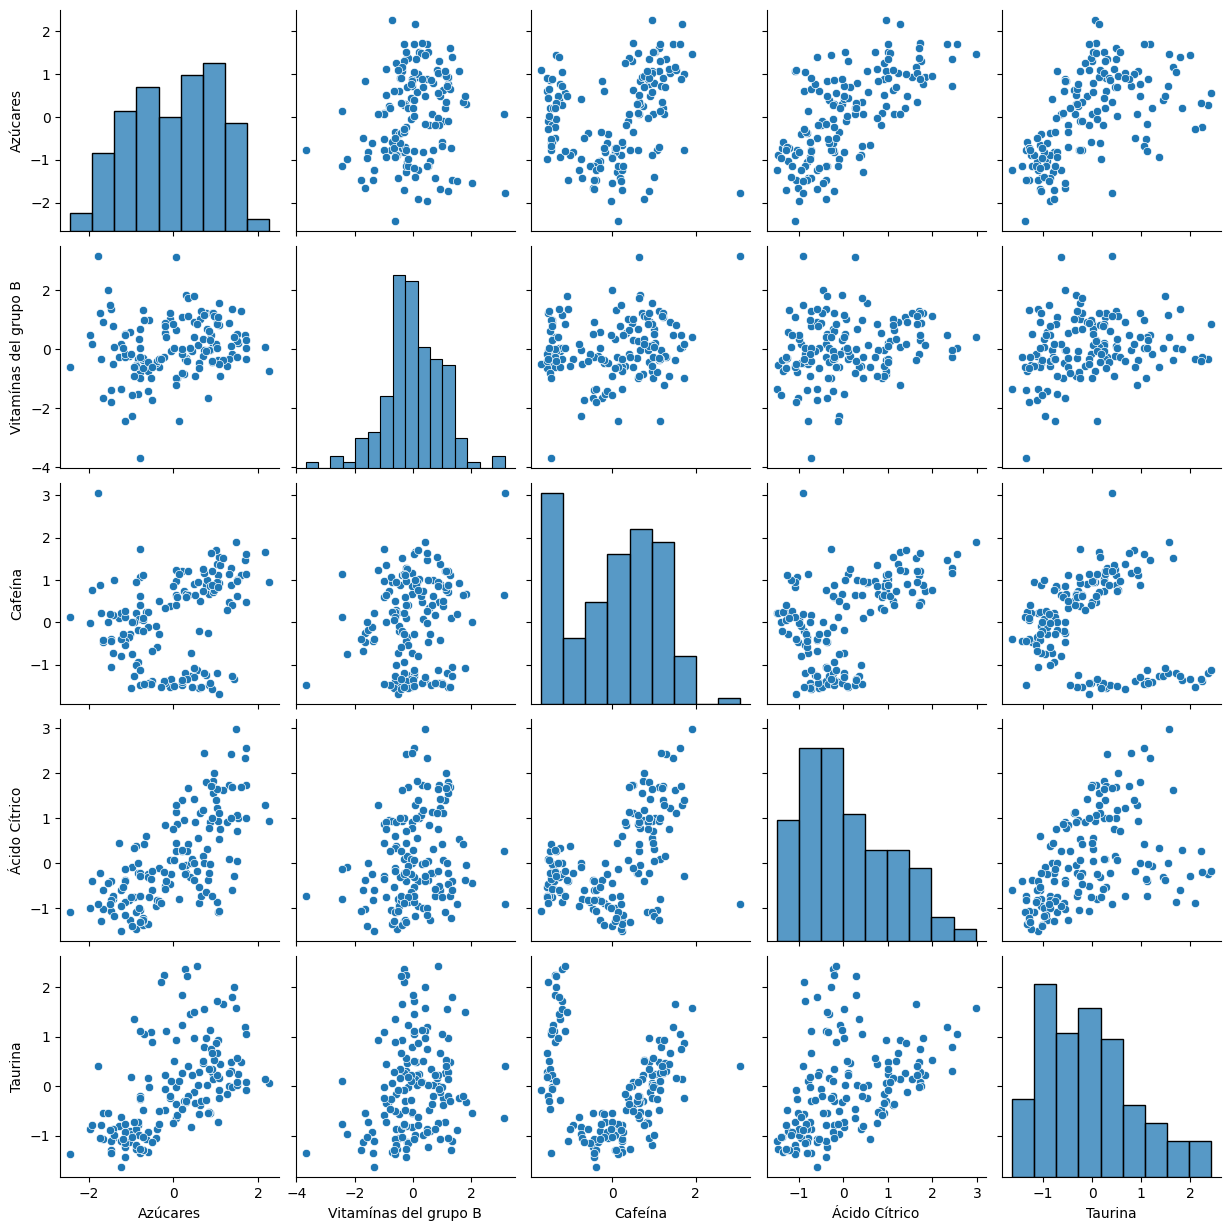

In [7]:
sns.pairplot(train_set)

In [8]:
for valores in combinations(train_set.columns, r=2):
    print(valores)

('Azúcares', 'Vitamínas del grupo B')
('Azúcares', 'Cafeína')
('Azúcares', 'Ácido Cítrico')
('Azúcares', 'Taurina')
('Vitamínas del grupo B', 'Cafeína')
('Vitamínas del grupo B', 'Ácido Cítrico')
('Vitamínas del grupo B', 'Taurina')
('Cafeína', 'Ácido Cítrico')
('Cafeína', 'Taurina')
('Ácido Cítrico', 'Taurina')


Azúcares vs Vitamínas del grupo B


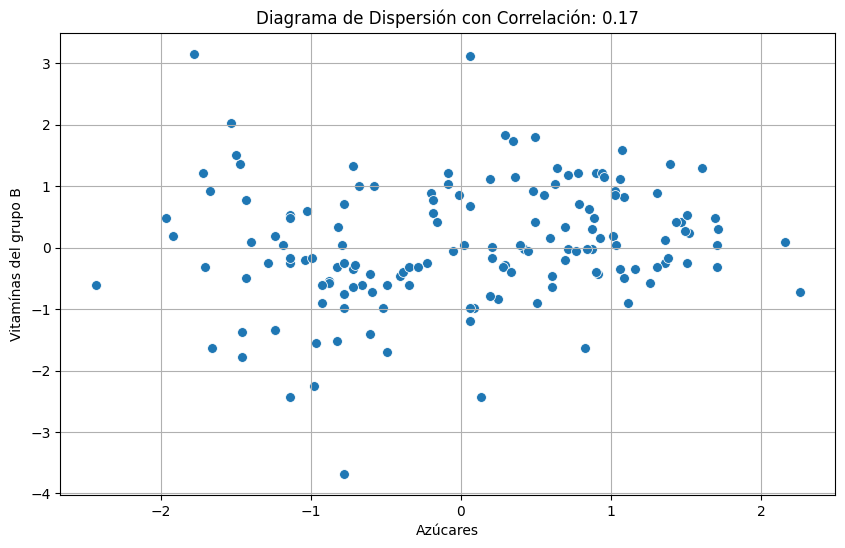

Azúcares vs Cafeína


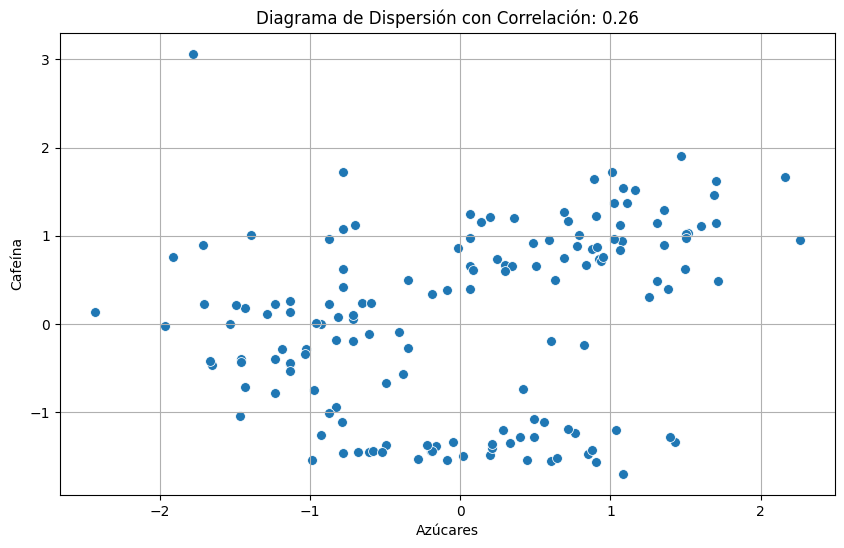

Azúcares vs Ácido Cítrico


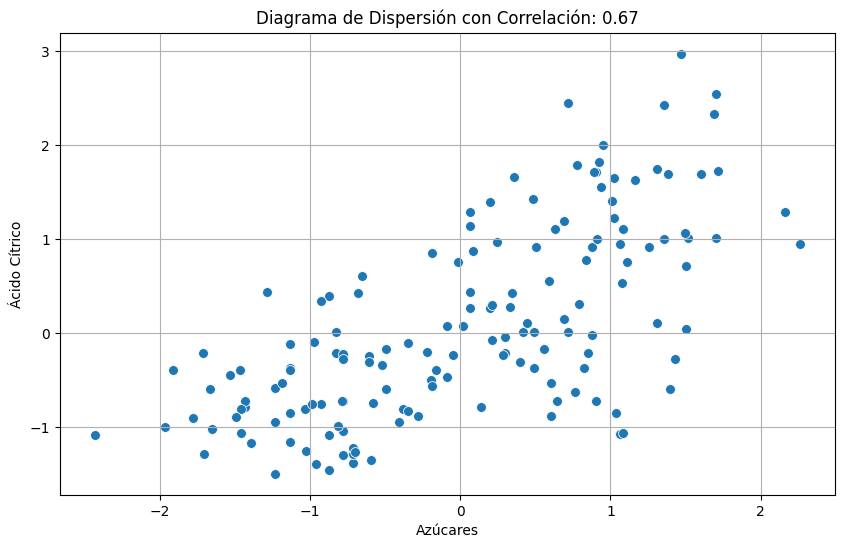

Azúcares vs Taurina


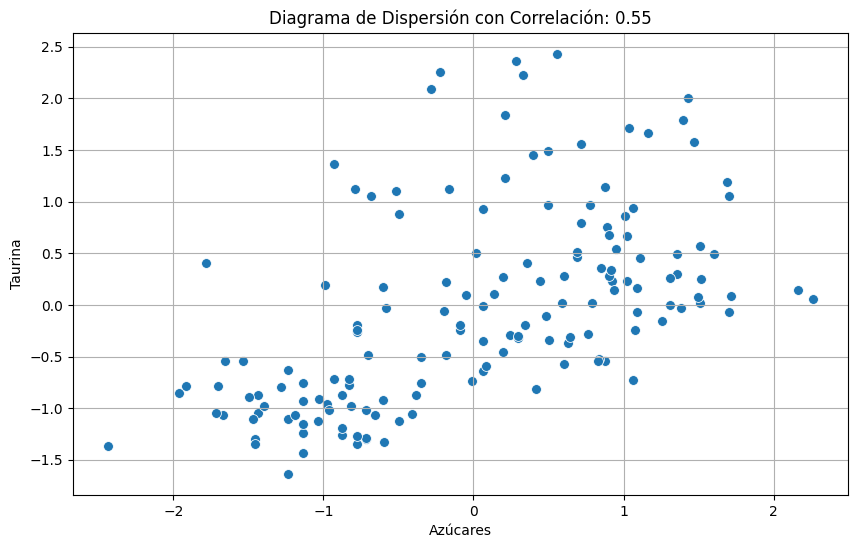

Vitamínas del grupo B vs Cafeína


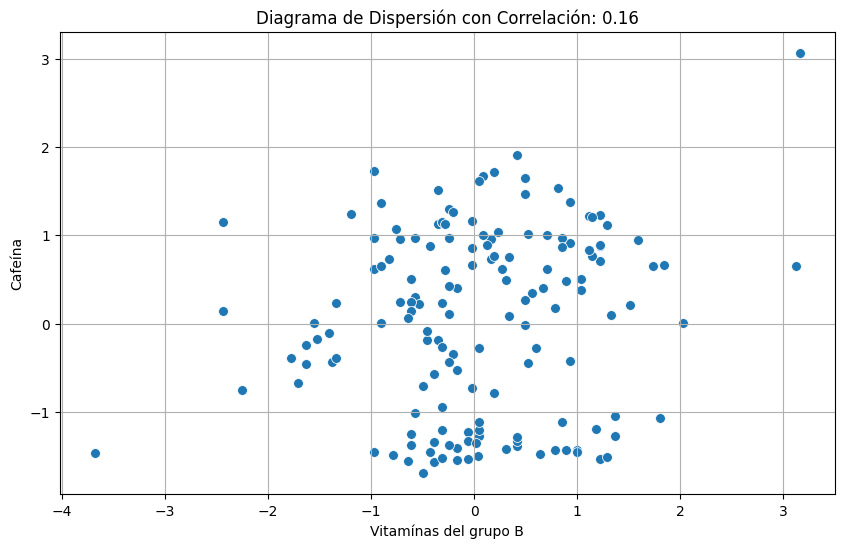

Vitamínas del grupo B vs Ácido Cítrico


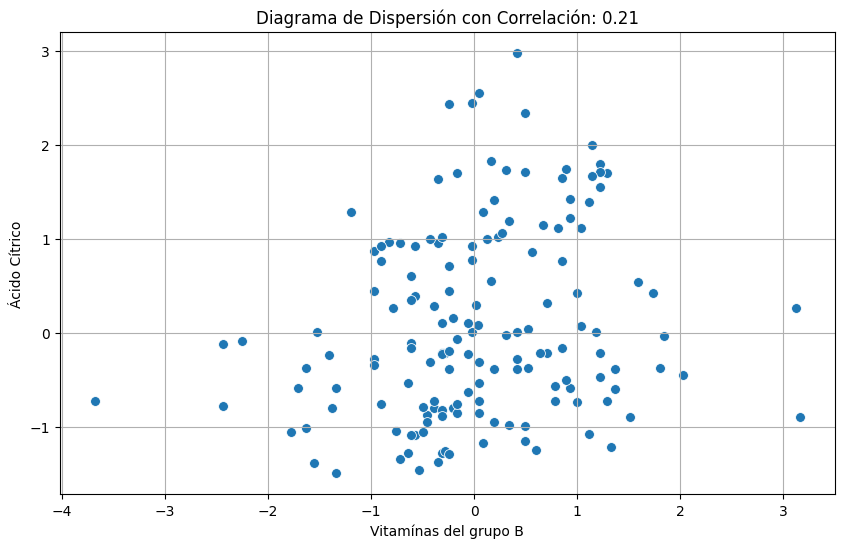

Vitamínas del grupo B vs Taurina


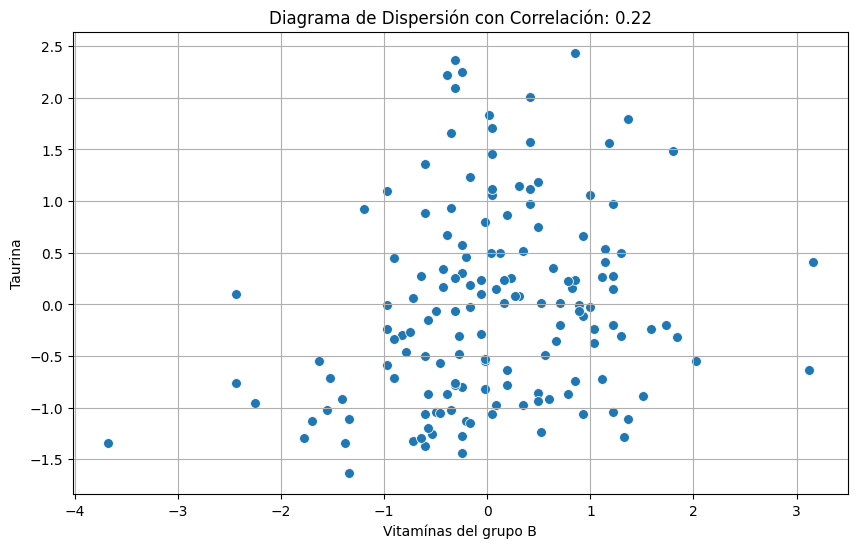

Cafeína vs Ácido Cítrico


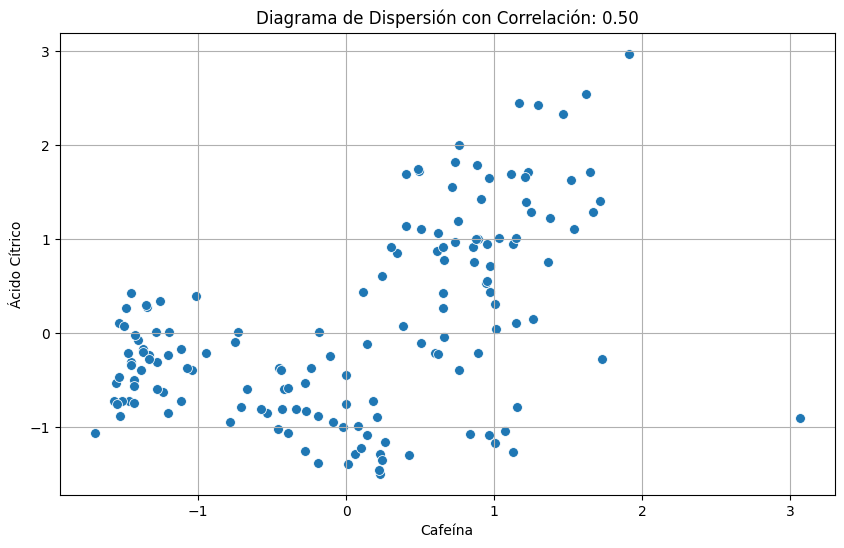

Cafeína vs Taurina


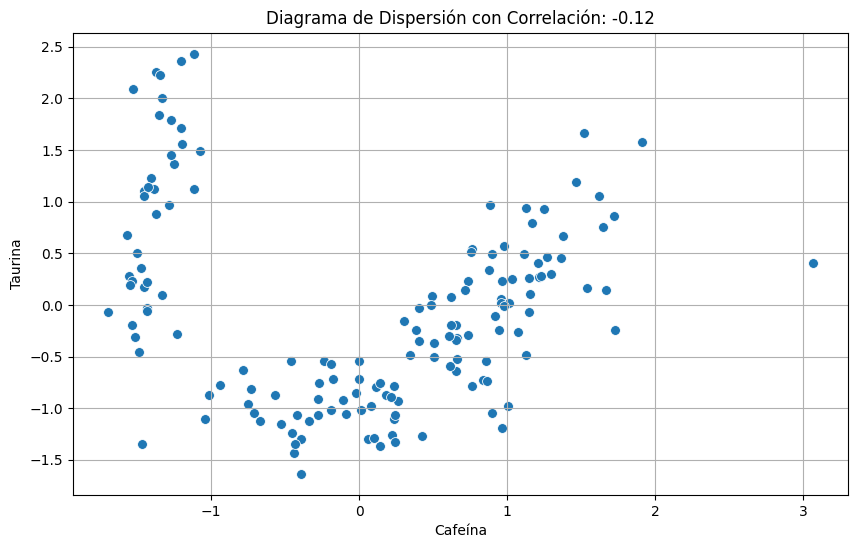

Ácido Cítrico vs Taurina


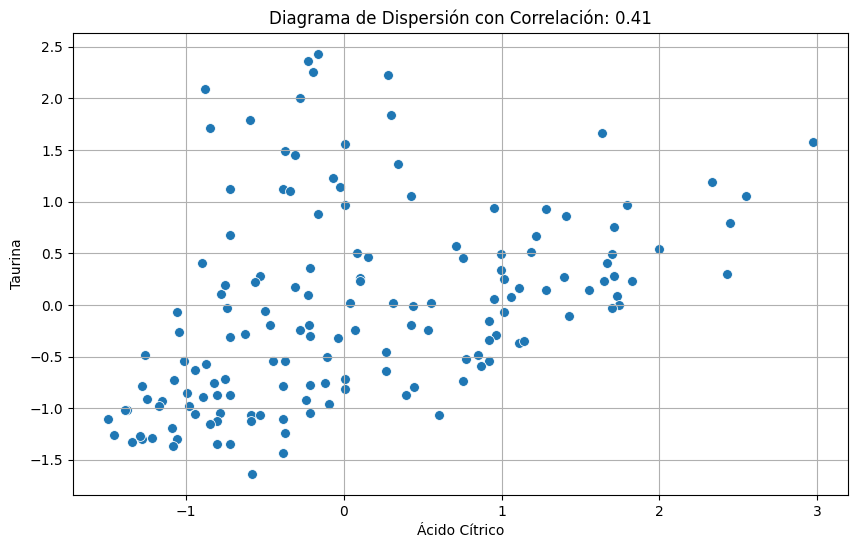

In [9]:
for x, y in combinations(train_set.columns, r=2):
    print(f'{x} vs {y}')
    bt.grafico_dispersion_con_correlacion(train_set, x, y, mostrar_correlacion=True)

Parece no haber clasters claros, todo parece bastante mezclado. Revisando los scatter individuales:
- La mayoría son brochazos sin separación clara
- Cafeína vs Taurina parece que tiene algo más de estructura, quizás dos o tres grupos
- Cafeína vs Azúcares también tiene algo

Me quedo con Cafeína y Taurina como las features más útiles para el modelo.

In [10]:
features_short = ["Cafeína", "Taurina"]
features = train_set.columns.to_list()

### 4. Tratamiento de features

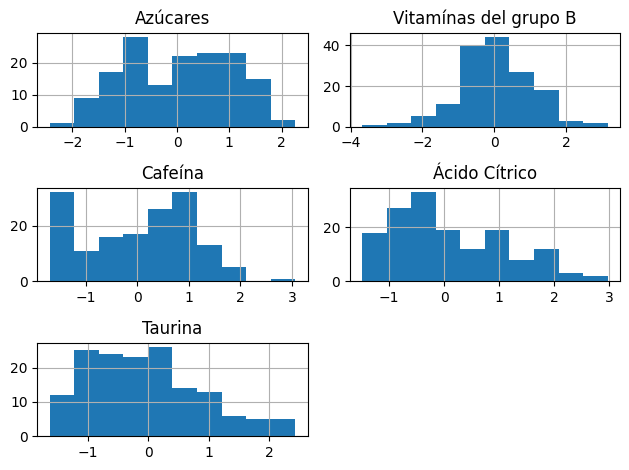

In [11]:
train_set.hist()
plt.tight_layout()

Como vimos antes los datos ya parecen escalados, se confirma al observar los histogramas.

In [12]:
train_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [13]:
np.linspace(0.001, 6, 100)

array([1.00000000e-03, 6.15959596e-02, 1.22191919e-01, 1.82787879e-01,
       2.43383838e-01, 3.03979798e-01, 3.64575758e-01, 4.25171717e-01,
       4.85767677e-01, 5.46363636e-01, 6.06959596e-01, 6.67555556e-01,
       7.28151515e-01, 7.88747475e-01, 8.49343434e-01, 9.09939394e-01,
       9.70535354e-01, 1.03113131e+00, 1.09172727e+00, 1.15232323e+00,
       1.21291919e+00, 1.27351515e+00, 1.33411111e+00, 1.39470707e+00,
       1.45530303e+00, 1.51589899e+00, 1.57649495e+00, 1.63709091e+00,
       1.69768687e+00, 1.75828283e+00, 1.81887879e+00, 1.87947475e+00,
       1.94007071e+00, 2.00066667e+00, 2.06126263e+00, 2.12185859e+00,
       2.18245455e+00, 2.24305051e+00, 2.30364646e+00, 2.36424242e+00,
       2.42483838e+00, 2.48543434e+00, 2.54603030e+00, 2.60662626e+00,
       2.66722222e+00, 2.72781818e+00, 2.78841414e+00, 2.84901010e+00,
       2.90960606e+00, 2.97020202e+00, 3.03079798e+00, 3.09139394e+00,
       3.15198990e+00, 3.21258586e+00, 3.27318182e+00, 3.33377778e+00,
      

### 5. DBSCAN de todas las features
Iteramos sobre distintos valores de eps y min_samples para ver cuándo el porcentaje de anomalías baja del 10%. Uso min_samples = 3, 5 y 10 porque el dataset no es muy grande (153 puntos).

In [14]:
outlier_percent = []
experiments = {}

for min_samples in [3, 5, 10]:
    print(f'Min_samples = {min_samples}')
    outlier_percent = []
    for eps in np.linspace(0.001, 6, 100):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(train_set)
        perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
        outlier_percent.append(perc_outliers)
    experiments[min_samples] = outlier_percent

Min_samples = 3
Min_samples = 5
Min_samples = 10


Generamos los rangos de valores de eps que vamos a probar.

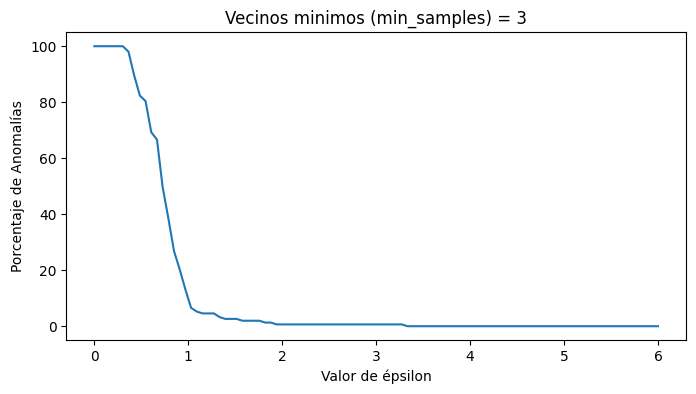

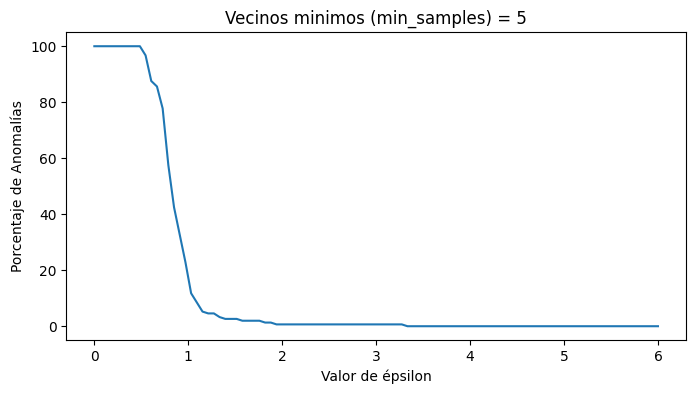

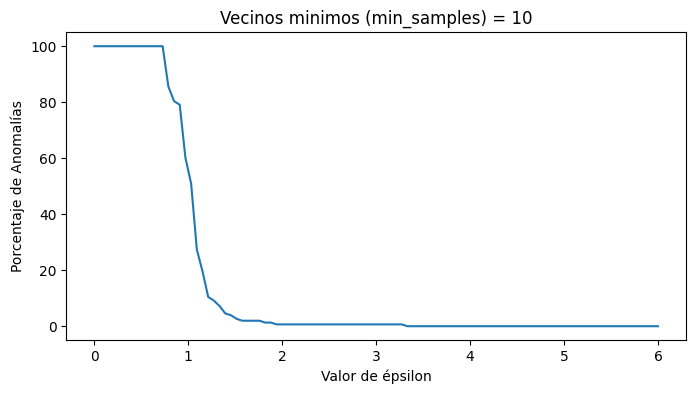

In [15]:
for min_samples in [3, 5, 10]:
    plt.figure(figsize=(8, 4), dpi=100)
    sns.lineplot(x=np.linspace(0.001, 6, 100), y=experiments[min_samples])
    plt.ylabel('Porcentaje de Anomalías')
    plt.xlabel('Valor de épsilon')
    plt.title(f'Vecinos minimos (min_samples) = {min_samples}')
    plt.show()

Entrenamos DBSCAN para cada combinación de eps y min_samples y guardo el porcentaje de anomalías. Las anomalías en DBSCAN se etiquetan como -1.

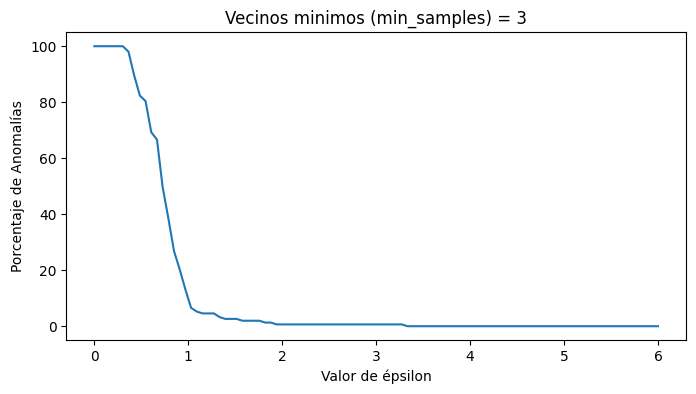

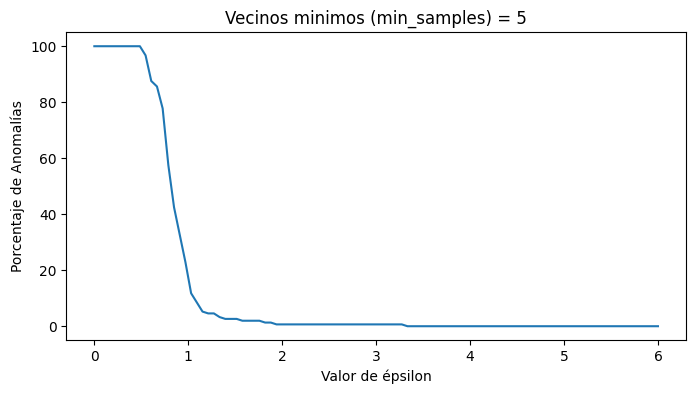

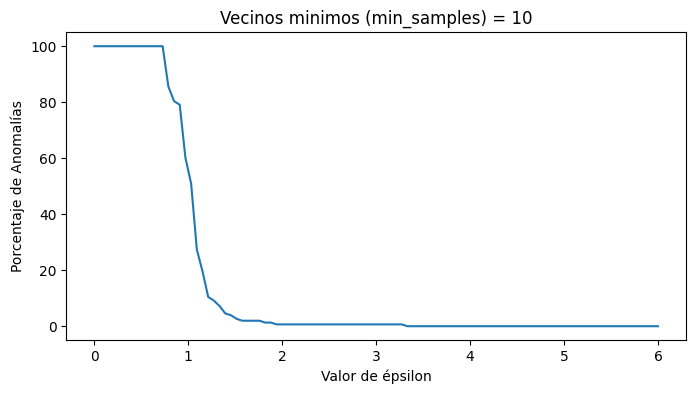

In [16]:
for min_samples in [3, 5, 10]:
    plt.figure(figsize=(8, 4), dpi=100)
    sns.lineplot(x=np.linspace(0.001, 6, 100), y=experiments[min_samples])
    plt.ylabel('Porcentaje de Anomalías')
    plt.xlabel('Valor de épsilon')
    plt.title(f'Vecinos minimos (min_samples) = {min_samples}')
    plt.show()

Se pinta el porcentaje de anomalías en función de eps para cada valor de min_samples. Vemso que entre eps = 1.2 y 2 el porcentaje baja del 10%.

In [17]:
for min_samples in [3, 5, 10]:
    print(f'Para num_samples = {min_samples}:')
    for indice, valor in enumerate(np.linspace(0.001, 6, 100)):
        if 1.2 <= valor <= 2:
            print(f'{valor} -> {experiments[min_samples][indice]}')

Para num_samples = 3:
1.2129191919191917 -> 4.57516339869281
1.2735151515151513 -> 4.57516339869281
1.334111111111111 -> 3.2679738562091503
1.3947070707070706 -> 2.6143790849673203
1.45530303030303 -> 2.6143790849673203
1.5158989898989896 -> 2.6143790849673203
1.5764949494949492 -> 1.9607843137254901
1.637090909090909 -> 1.9607843137254901
1.6976868686868685 -> 1.9607843137254901
1.758282828282828 -> 1.9607843137254901
1.8188787878787878 -> 1.3071895424836601
1.8794747474747473 -> 1.3071895424836601
1.9400707070707068 -> 0.6535947712418301
Para num_samples = 5:
1.2129191919191917 -> 4.57516339869281
1.2735151515151513 -> 4.57516339869281
1.334111111111111 -> 3.2679738562091503
1.3947070707070706 -> 2.6143790849673203
1.45530303030303 -> 2.6143790849673203
1.5158989898989896 -> 2.6143790849673203
1.5764949494949492 -> 1.9607843137254901
1.637090909090909 -> 1.9607843137254901
1.6976868686868685 -> 1.9607843137254901
1.758282828282828 -> 1.9607843137254901
1.8188787878787878 -> 1.3071895

Imprimo los valores exactos para el rango de eps entre 1.2 y 2

In [18]:
for min_samples in [3, 5, 10]:
    dbscan = DBSCAN(eps=1.3, min_samples=min_samples)
    dbscan.fit(train_set)
    print(f'Para {min_samples} de vecinos: {pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()} clusters')

Para 3 de vecinos: 1 clusters
Para 5 de vecinos: 1 clusters
Para 10 de vecinos: 1 clusters


Con eps=1.3 solo sale 1 cluster para todos los valores de min_samples. Necesito reducir eps para que el modelo sea más estricto y encuentre más clusters. Probamos con eps = 1.0

In [19]:
dbscan = DBSCAN(eps=1.0, min_samples=3)
dbscan.fit(train_set)
print(f'Para min_samples=3: {pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()} clusters')

Para min_samples=3: 4 clusters


Vemos que mejora pero sigue sin llegar a 3 clusters. Con min_samples=3 y eps=1.0 obtengo algo más de separación.

In [20]:
train_set

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276
...,...,...,...,...,...
148,0.493343,0.414820,-1.284344,0.009893,0.969783
149,0.332758,-0.389355,-1.344582,0.280575,2.224236
150,0.209232,0.012732,-1.354622,0.296498,1.834923
151,1.395086,1.365208,-1.274305,-0.595160,1.791666


In [21]:
train_set_all = train_set.copy()
train_set_all['Cluster'] = dbscan.labels_

Solo con 10 vecinos conseguimos 3 clusters pero el porcentaje de anomalías ya supera el 10%. Vamos a ver cómo queda visualmente con eps=1.0 y min_samples=10.

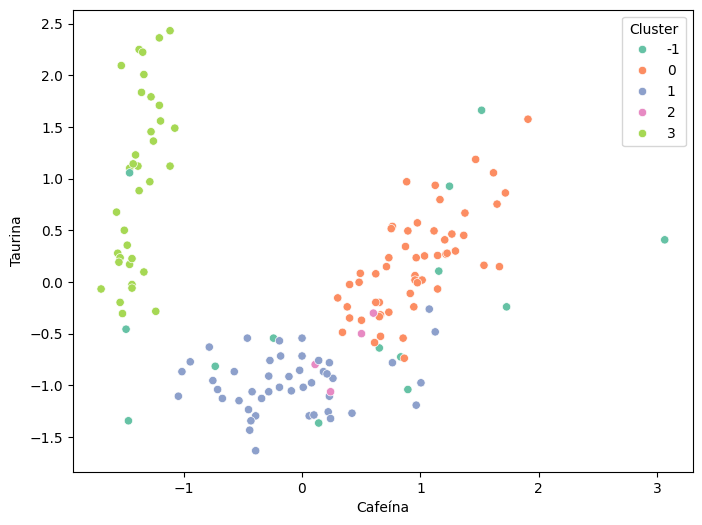

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_set_all[['Cafeína', 'Taurina', 'Cluster']],
                x='Cafeína', y='Taurina', hue='Cluster', palette='Set2')
plt.show()

In [23]:
train_set[features_short]

,Cafeína,Taurina
0,1.034819,0.251717
1,0.733629,-0.293321
2,1.215533,0.269020
3,1.466525,1.186068
4,0.663351,-0.319276
...,...,...
148,-1.284344,0.969783
149,-1.344582,2.224236
150,-1.354622,1.834923
151,-1.274305,1.791666


Seleccionamos solo dos features:

In [24]:
outlier_percent = []
experiments = {}
for min_samples in [3, 5, 10]:
    print(f'Min_samples = {min_samples}')
    outlier_percent = []
    for eps in np.linspace(0.001, 6, 100):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(train_set[features_short])
        perc_outliers = 100 * np.sum(dbscan.labels_ == -1) / len(dbscan.labels_)
        outlier_percent.append(perc_outliers)
    experiments[min_samples] = outlier_percent

Min_samples = 3
Min_samples = 5
Min_samples = 10


Repetimos el mismo proceso pero ahora solo con Cafeína y Taurina. Al tener menos dimensiones el modelo debería funcionar mejor

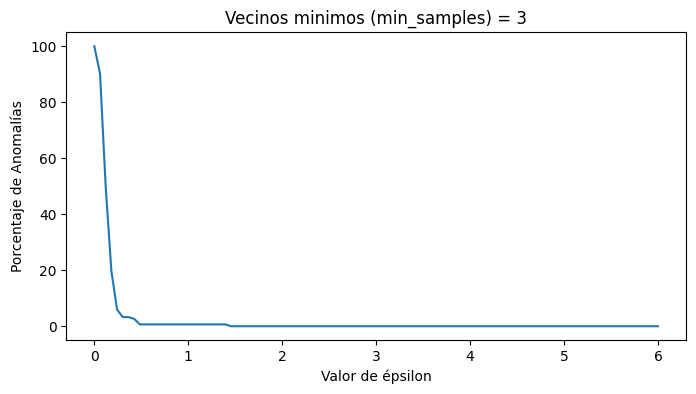

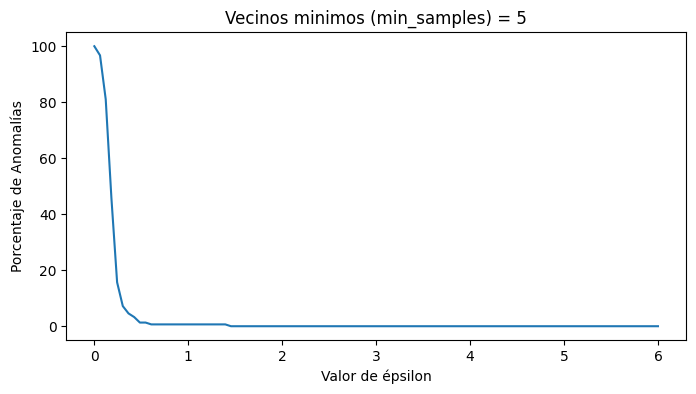

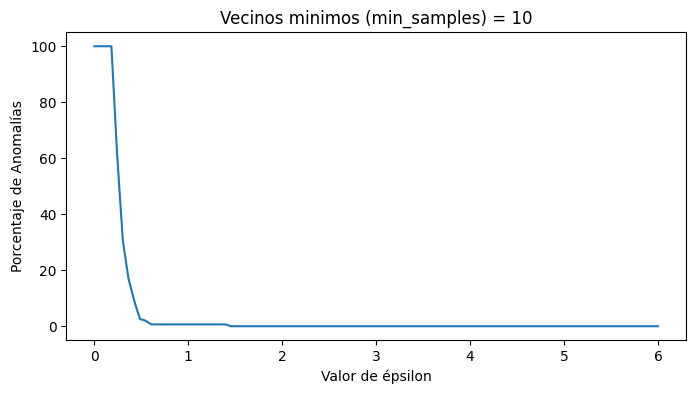

In [25]:
for min_samples in [3, 5, 10]:
    plt.figure(figsize=(8, 4), dpi=100)
    sns.lineplot(x=np.linspace(0.001, 6, 100), y=experiments[min_samples])
    plt.ylabel('Porcentaje de Anomalías')
    plt.xlabel('Valor de épsilon')
    plt.title(f'Vecinos minimos (min_samples) = {min_samples}')
    plt.show()

In [26]:
for min_samples in [3, 5, 10]:
    dbscan = DBSCAN(eps=0.5, min_samples=min_samples)
    dbscan.fit(train_set[features_short])
    print(f'Para {min_samples} de vecinos: {pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()} clusters')

Para 3 de vecinos: 2 clusters
Para 5 de vecinos: 2 clusters
Para 10 de vecinos: 2 clusters


In [27]:
for min_samples in [3, 5, 10]:
    dbscan = DBSCAN(eps=0.3, min_samples=min_samples)
    dbscan.fit(train_set[features_short])
    print(f'Para {min_samples} de vecinos: {pd.Series(dbscan.labels_[dbscan.labels_ != -1]).nunique()} clusters')

Para 3 de vecinos: 3 clusters
Para 5 de vecinos: 4 clusters
Para 10 de vecinos: 3 clusters


Con eps=0.3 y min_samples=5 obtengo 4 clusters. Con min_samples=3 también sale bien. Voy a quedarme con min_samples=10 para ver cómo queda.

In [28]:
pd.Series(dbscan.labels_).value_counts()

 0    51
-1    49
 1    40
 2    13
Name: count, dtype: int64

In [29]:
train_set_2feat = pd.DataFrame(train_set).copy()
train_set_2feat['Cluster'] = dbscan.labels_

Añadimos las etquetas al dataset con 2 features

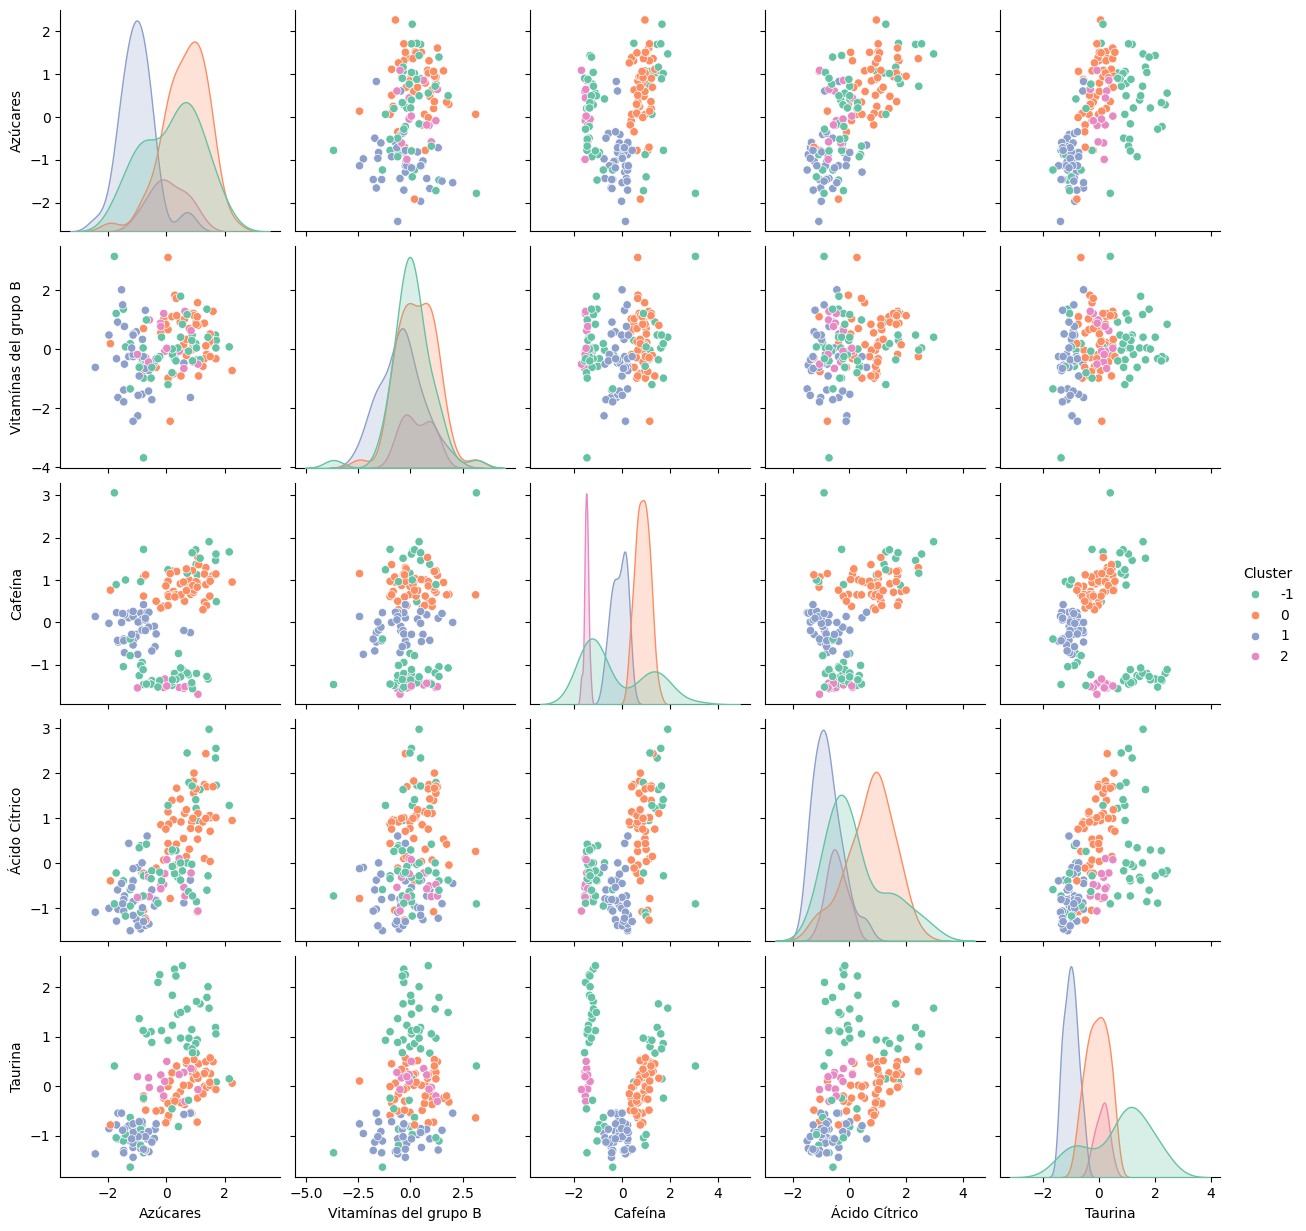

In [30]:
sns.pairplot(train_set_2feat, hue="Cluster", palette="Set2");

<Axes: xlabel='Cafeína', ylabel='Taurina'>

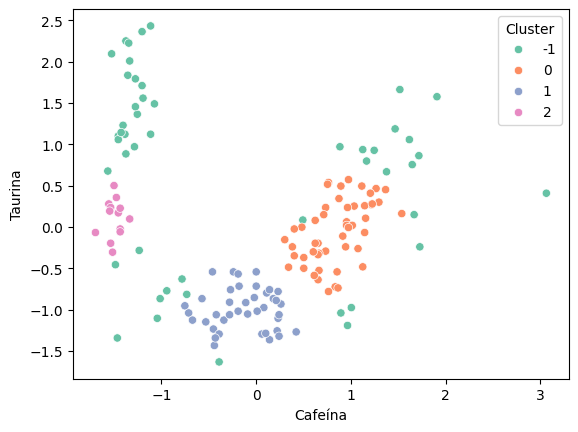

In [31]:
sns.scatterplot(data=train_set_2feat, x='Cafeína', y='Taurina', hue='Cluster', palette='Set2')

Hay demasiadas anomalías con min_samples=10. Voy a probar con min_samples=3 que debería dar menos anomalías.

In [32]:
train_set_2f = train_set.copy()

dbscan_3 = DBSCAN(eps=0.3, min_samples=3)
dbscan_3.fit(train_set[features_short])

train_set_2f['Cluster'] = dbscan_3.labels_

Entreno el modelo final de DBSCAN con eps=0.3 y min_samples=3. Guardo las etiquetas en el dataset.

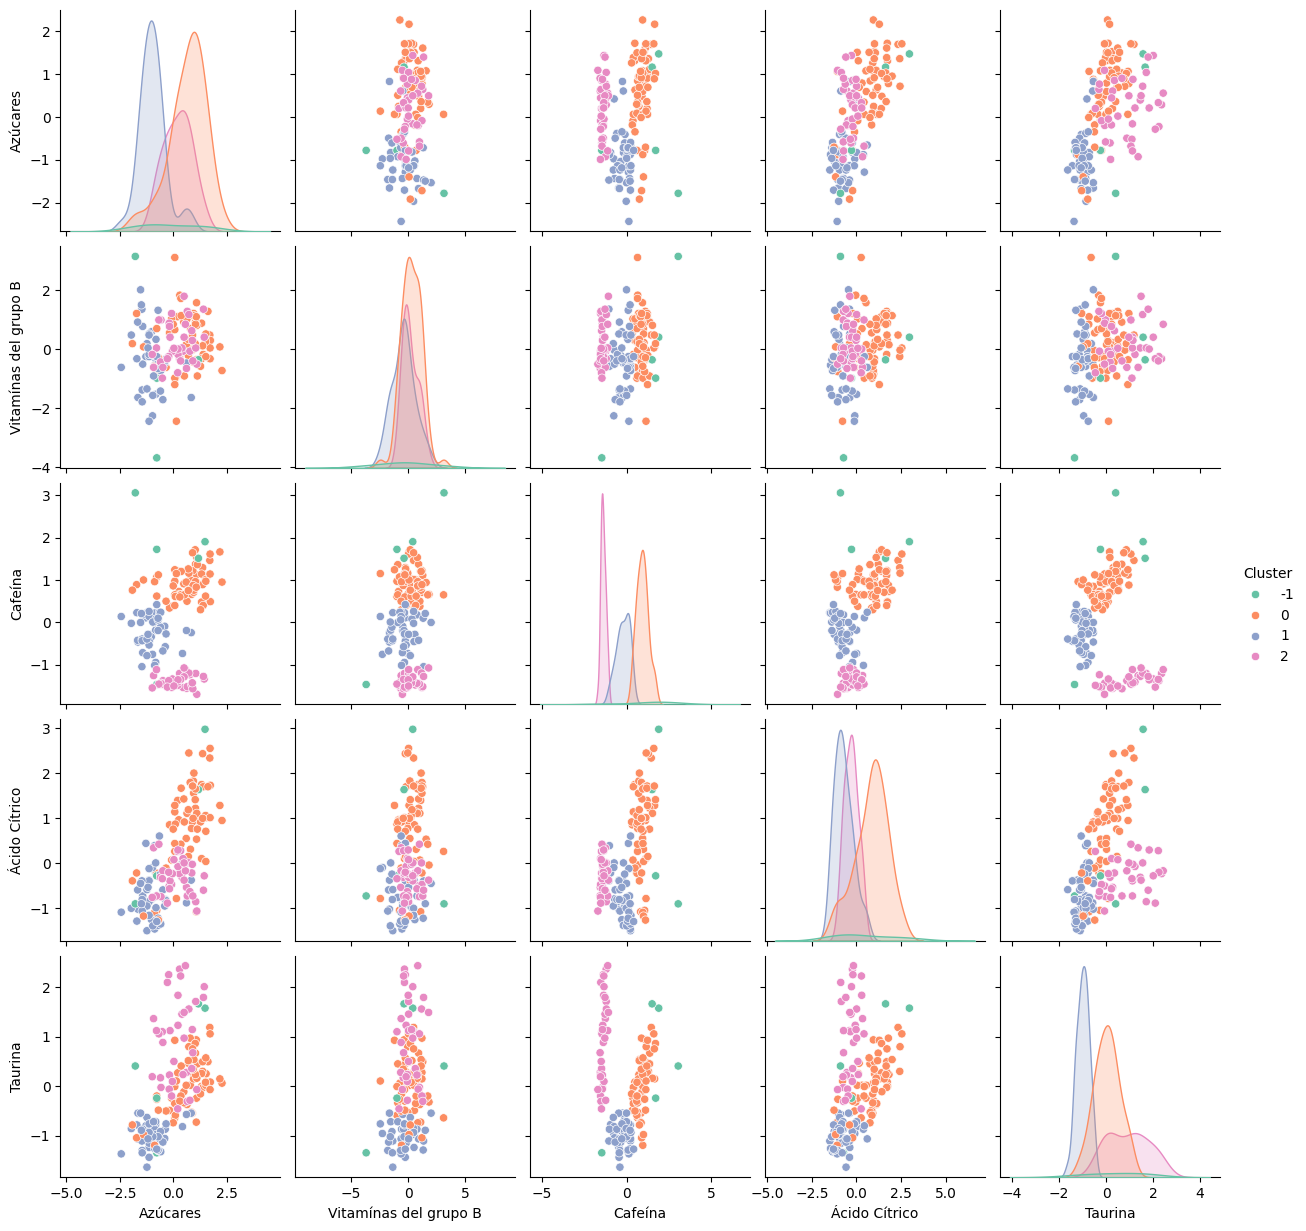

In [33]:
sns.pairplot(train_set_2f, hue="Cluster", palette="Set2");

<Axes: xlabel='Cafeína', ylabel='Taurina'>

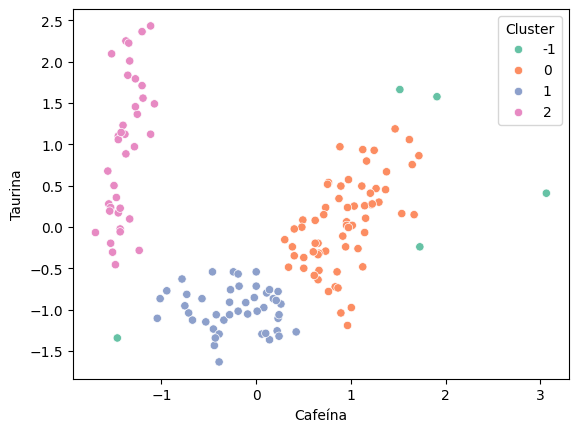

In [34]:
sns.scatterplot(data=train_set_2f, x='Cafeína', y='Taurina', hue='Cluster', palette='Set2')

### 6. Hacemos el clusting jerárquico
Para el clustering jerárquico voy a usar el método ward y las mismas dos features que funcionaron bien con DBSCAN (Cafeína y Taurina). El dendrograma me dirá cuántos clusters usar.

In [35]:
train_set[features_short]

,Cafeína,Taurina
0,1.034819,0.251717
1,0.733629,-0.293321
2,1.215533,0.269020
3,1.466525,1.186068
4,0.663351,-0.319276
...,...,...
148,-1.284344,0.969783
149,-1.344582,2.224236
150,-1.354622,1.834923
151,-1.274305,1.791666


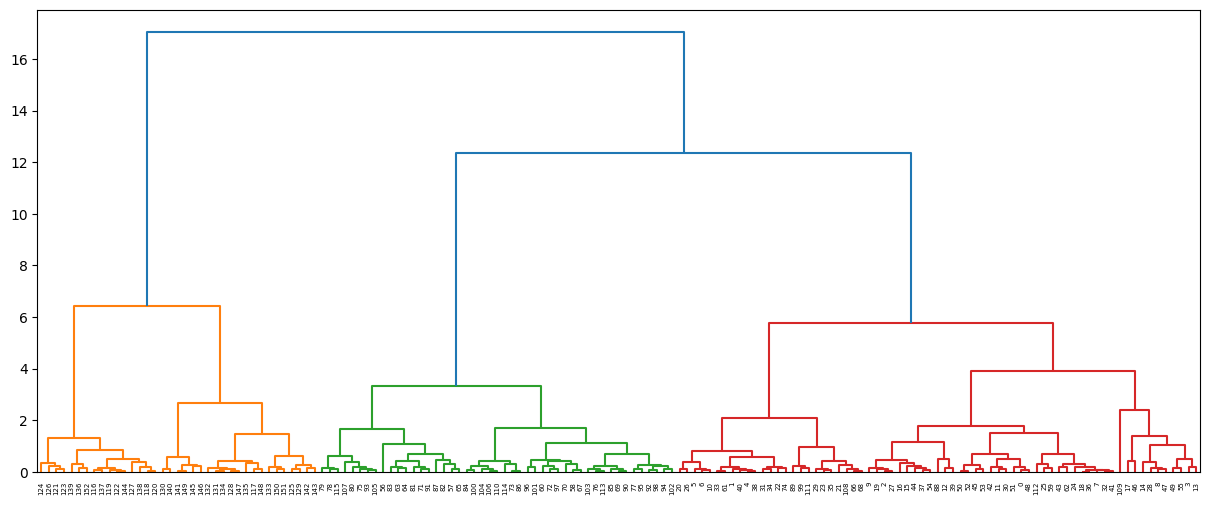

In [36]:
link_method = linkage(train_set[features_short], method='ward')

plt.figure(figsize=(15, 6))
dend = dendrogram(link_method)

En el dendrograma con el método ward podemos ver que hay un salto grande que sugiere 3 clusters principales.

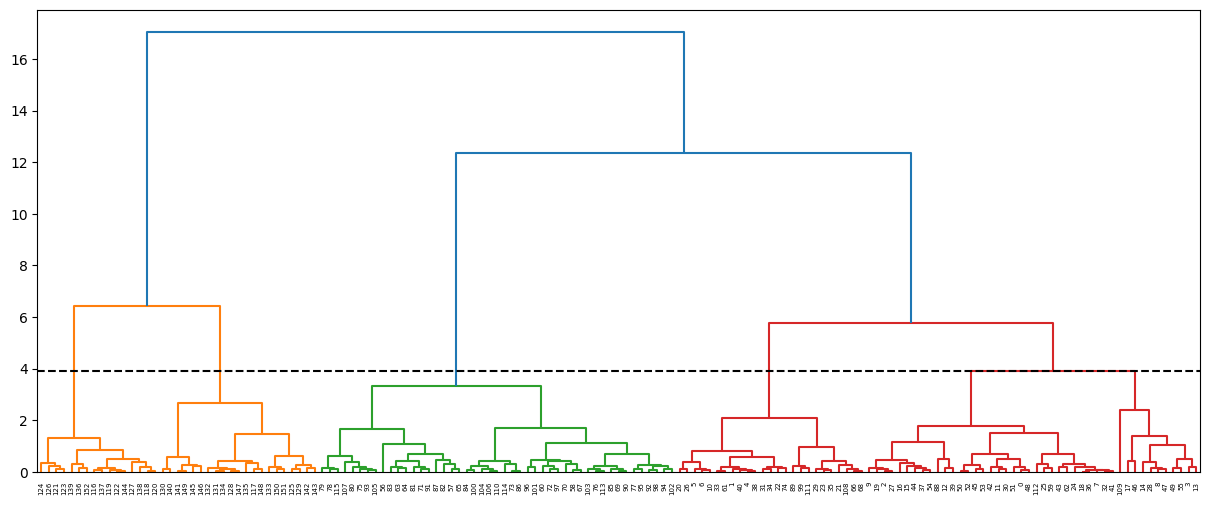

In [37]:
plt.figure(figsize=(15, 6))
dend = dendrogram(link_method)
plt.axhline(y=3.9, color='k', linestyle='--')
plt.show()

In [38]:
clustering_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clustering_model.fit(train_set[features_short])

train_set_agg = train_set.copy()
train_set_agg['Cluster'] = clustering_model.labels_

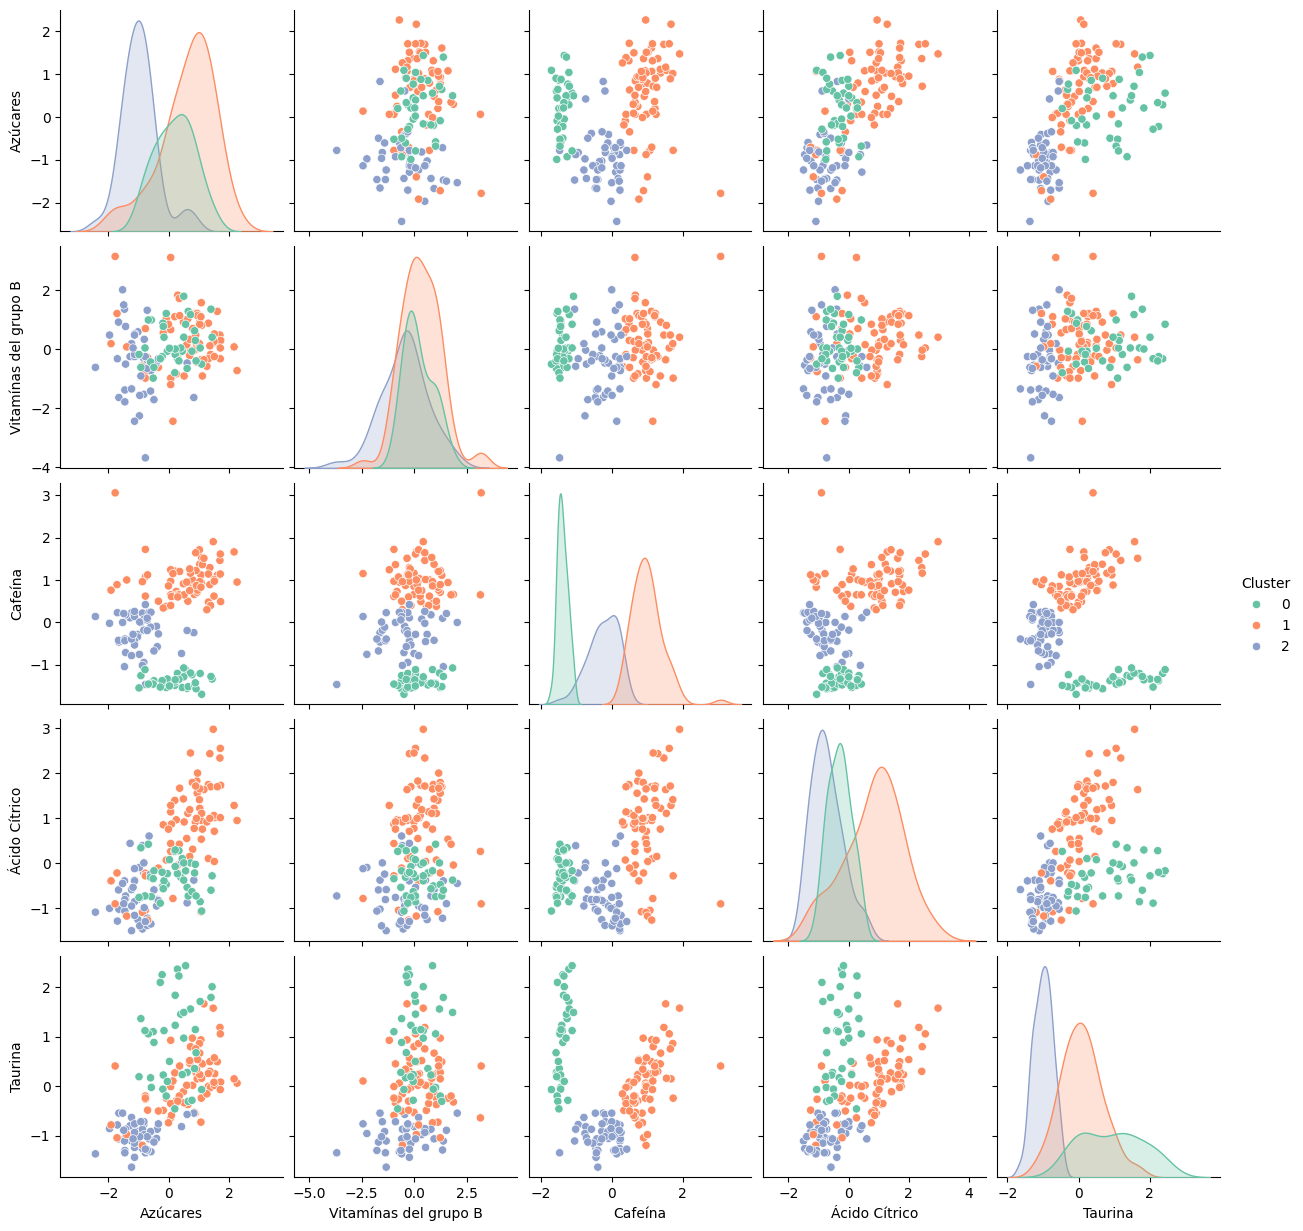

In [39]:
sns.pairplot(train_set_agg, hue="Cluster", palette="Set2")

<Axes: xlabel='Cafeína', ylabel='Taurina'>

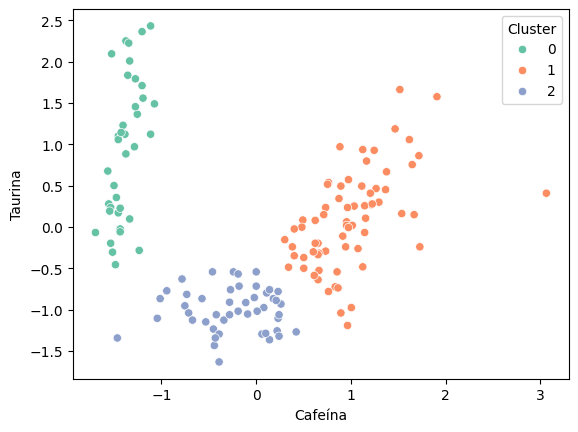

In [40]:
sns.scatterplot(data=train_set_agg, x='Cafeína', y='Taurina', hue='Cluster', palette='Set2')

Los clusters del jerárquico son muy similares a los de DBSCAN en Cafeína-Taurina. La diferencia es que el jerárquico no tiene anomalías, asigna todos los puntos a algún cluster.

In [41]:
clustering_model.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 2, 2,
       1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       2, 1, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [42]:
train_set_agg["Cluster"].value_counts()

Cluster
1    69
2    47
0    37
Name: count, dtype: int64

In [43]:
train_set_agg.loc[124]

Azúcares                 0.765101
Vitamínas del grupo B   -0.060375
Cafeína                 -1.234146
Ácido Cítrico           -0.627005
Taurina                 -0.284670
Cluster                  0.000000
Name: 124, dtype: float64

In [44]:
print(f"Cluster naranja: {train_set_agg.loc[124]['Cluster']}")
print(f"Cluster verde: {train_set_agg.loc[79]['Cluster']}")
print(f"Cluster rojo: {train_set_agg.loc[1]['Cluster']}")

Cluster naranja: 0.0
Cluster verde: 2.0
Cluster rojo: 1.0


Mirando el dendrograma, el cluster rojo y el verde están a distancia de aprox 12 entre sí, y estos dos están a aprozx 18 del cluster naranja. Esto puede ser útil para los químicos para saber qué mezclas son más similares entre sí.

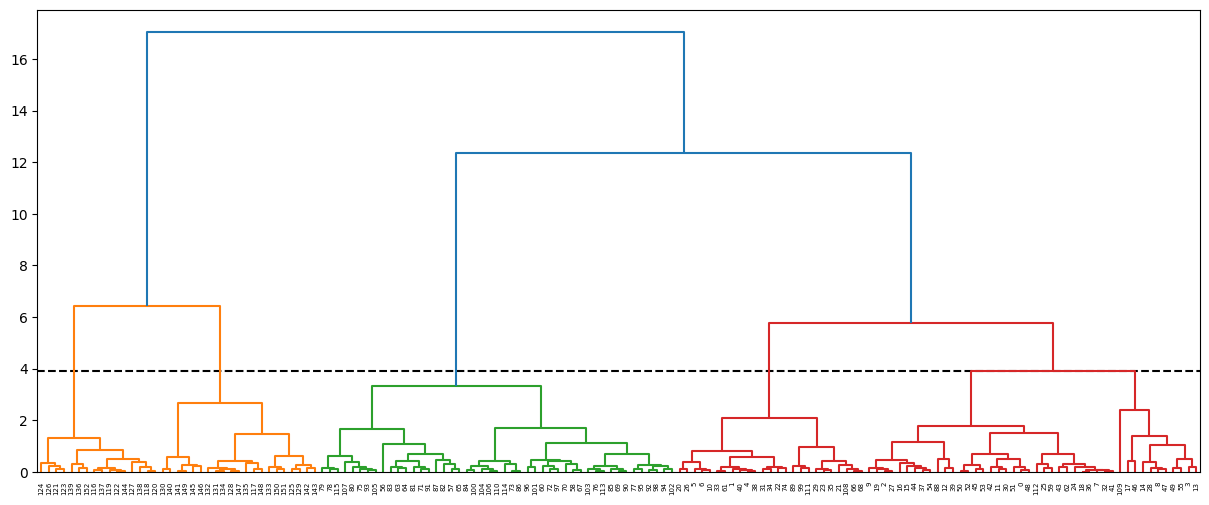

In [45]:
link_method = linkage(train_set[features_short], method='ward')
plt.figure(figsize=(15, 6))
plt.axhline(y=3.91456299, color='k', linestyle='--')
dend = dendrogram(link_method)

In [46]:
link_method[:-10:-1]

array([[302.        , 303.        ,  17.05969203, 153.        ],
       [299.        , 301.        ,  12.34117438, 116.        ],
       [289.        , 298.        ,   6.42831329,  37.        ],
       [296.        , 300.        ,   5.7867262 ,  69.        ],
       [295.        , 297.        ,   3.91456299,  44.        ],
       [293.        , 294.        ,   3.33685847,  47.        ],
       [274.        , 291.        ,   2.65562654,  21.        ],
       [109.        , 290.        ,   2.37800925,  11.        ],
       [282.        , 284.        ,   2.09800379,  25.        ]])

In [47]:
train_set_agg["Cluster"].value_counts()

Cluster
1    69
2    47
0    37
Name: count, dtype: int64

In [48]:
link_method[-2:]

array([[299.        , 301.        ,  12.34117438, 116.        ],
       [302.        , 303.        ,  17.05969203, 153.        ]])

**Conclusión Parte I:** Tanto DBSCAN como el clustering jerárquico encuentran 3 grupos similares. Sin target no podemos confirmar cuál es mejor, pero ambos tienen sentido visualmente.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [49]:
X_new = pd.read_csv("./data/new_experiments.csv", sep="|")

In [50]:
X_new.head(10)

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043


Vemos que los nuevos experimetnos tienen las mismas columnas que el dataset original

In [51]:
clustering_model.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 2, 2,
       1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       2, 1, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [52]:
new_train_set = pd.concat([train_set, X_new])

Para el clustering jerárquico no puedo predecir directamente sobre nuevos datos. Lo que hago es concatenar los nuevos datos con los originales y volver a entrenar

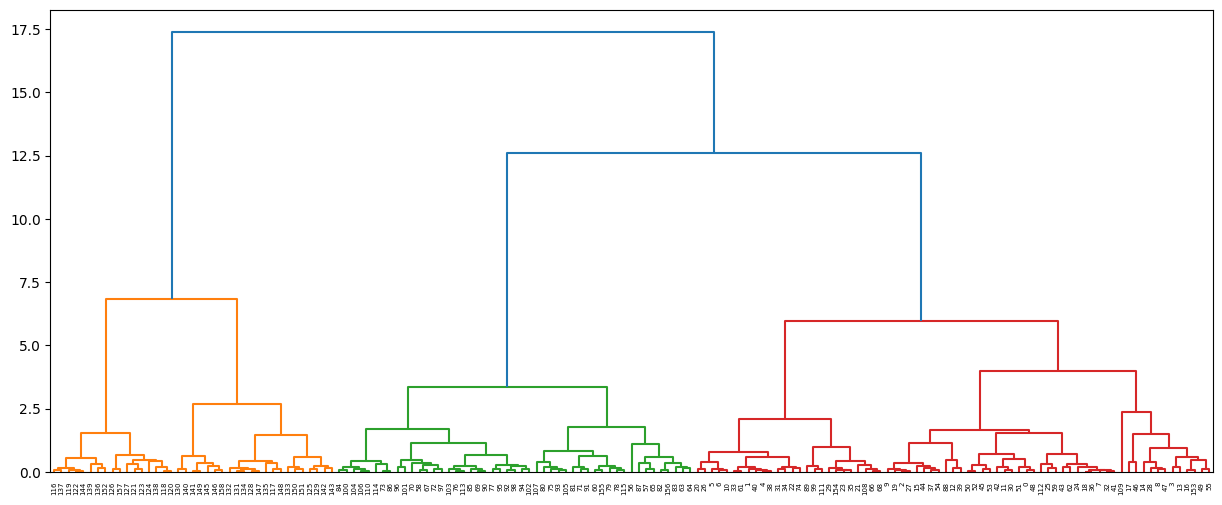

In [53]:
link_method = linkage(new_train_set[features_short], method='ward')
plt.figure(figsize=(15, 6))
dend = dendrogram(link_method)

In [54]:
clustering_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clustering_model.fit(new_train_set[features_short])

new_train_set_agg = new_train_set.copy()
new_train_set_agg['Cluster'] = clustering_model.labels_

In [55]:
new_train_set_agg.tail(len(X_new))

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,Cluster
0,1.481555,0.305159,1.366128,2.239039,0.731870,1
1,0.616869,0.890014,0.583034,0.312420,-0.665332,1
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,2
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,2
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,0
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,0


In [56]:
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()
target = 'Cluster'
X_train = train_set_2f.drop(target, axis=1)
y_train = train_set_2f[target]

In [57]:
param_grid = {
    'n_neighbors': [2, 3, 5, 10],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(knn,
                        param_grid=param_grid,
                        cv=4,
                        scoring='balanced_accuracy')

knn_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [2, 3, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also d

In [58]:
knn_grid.best_params_

{'n_neighbors': 2, 'weights': 'uniform'}

In [59]:
knn_grid.best_score_

np.float64(0.7747395833333334)

In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_train, knn_grid.best_estimator_.predict(X_train)))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00         5
           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00        46
           2       1.00      1.00      1.00        37

    accuracy                           1.00       153
   macro avg       1.00      1.00      1.00       153
weighted avg       1.00      1.00      1.00       153



Vemos que el KNN ha aprendido!! 

In [61]:
y_pred = knn_grid.best_estimator_.predict(X_new)

In [62]:
X_new["Cluster"] = y_pred

In [63]:
train_set_2f.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,Cluster
0,1.518613,0.232053,1.034819,1.013009,0.251717,0
1,0.246290,-0.827996,0.733629,0.965242,-0.293321,0
2,0.196879,1.109334,1.215533,1.395148,0.269020,0
3,1.691550,0.487926,1.466525,2.334574,1.186068,0
4,0.295700,1.840403,0.663351,-0.037874,-0.319276,0


In [64]:
train_set_2f.merge(new_train_set_agg, left_index=True, right_index=True,
                   suffixes=['_DBSCAN', '_Agglo'])[['Cluster_DBSCAN', 'Cluster_Agglo']].value_counts()

Cluster_DBSCAN  Cluster_Agglo
 0              1                67
 1              2                46
 2              0                37
-1              1                 4
 0              2                 2
                0                 2
-1              2                 1
Name: count, dtype: int64

Los dos modelos hacen básicamente la misma clasificación, solo cambian los nombres de las etiquetas. La clase 0 de DBSCAN corresponde a la 1 del jerárquico, la 1 a la 2 y la 2 a la 0. Además DBSCAN tiene algunas anomalías (-1) que el jerárquico asigna a algún cluster.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.